Failed to get ticker '8299.TW' reason: HTTPSConnectionPool(host='fc.yahoo.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)')))
[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['8299.TW']: YFTzMissingError('$%ticker%: possibly delisted; No timezone found')


Empty DataFrame
Columns: [Open, High, Low, Close, Adj Close, Volume]
Index: []


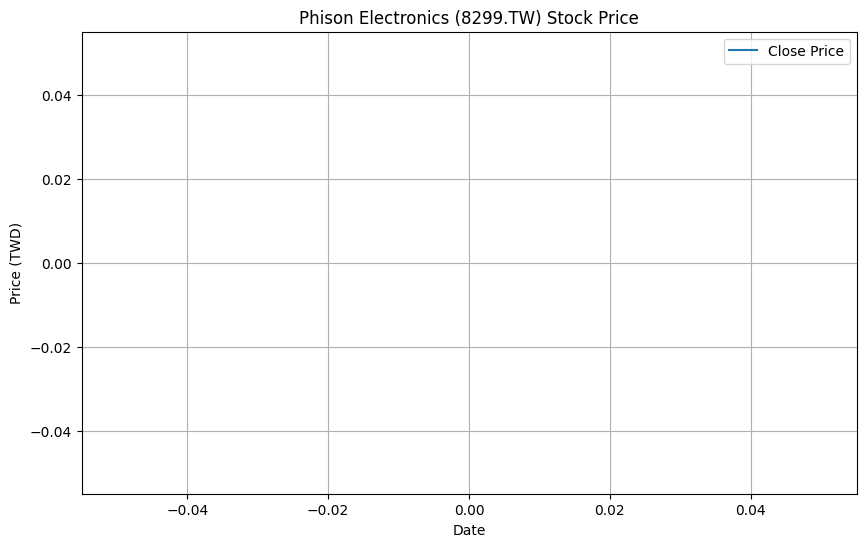

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

# 設定股票代號和時間範圍
stock_symbol = "8299.TW"  # 群聯電子的股票代號，.TW 表示台灣市場
start_date = "2022-10-01"
end_date = "2023-10-01"

# 使用 yfinance 下載股價數據
stock_data = yf.download(stock_symbol, start=start_date, end=end_date)

# 顯示前幾行數據
print(stock_data.head())

# 繪製股價走勢圖
plt.figure(figsize=(10, 6))
plt.plot(stock_data['Close'], label='Close Price')
plt.title('Phison Electronics (8299.TW) Stock Price')
plt.xlabel('Date')
plt.ylabel('Price (TWD)')
plt.legend()
plt.grid()
plt.show()

In [8]:
import numpy as np
import pandas as pd

# 初始條件
initial_investment = 30_000_000  # 貸款金額
annual_interest = 0.03 * initial_investment  # 每年利息支出
years_to_retirement = 5
years_after_retirement = 10
total_years = years_to_retirement + years_after_retirement

# 投資組合配置與資產特性（報酬率與波動率）
portfolio = {
    "高股息ETF": {"比例": 0.3, "年報酬率": 0.06, "波動率": 0.10},
    "債券基金": {"比例": 0.3, "年報酬率": 0.045, "波動率": 0.05},
    "REITs": {"比例": 0.2, "年報酬率": 0.055, "波動率": 0.08},
    "不動產基金": {"比例": 0.2, "年報酬率": 0.065, "波動率": 0.12}
}

# 模擬每年資產變化與現金流
np.random.seed(42)
results = []

# 初始資產分配
assets = {name: initial_investment * data["比例"] for name, data in portfolio.items()}

for year in range(1, total_years + 1):
    year_result = {"年份": year, "總資產": 0, "總現金流": 0}
    total_value = 0
    total_cashflow = 0

    for name, data in portfolio.items():
        # 模擬該資產的年報酬率（考慮波動）
        simulated_return = np.random.normal(data["年報酬率"], data["波動率"])
        # 現金流為該資產的配息部分（假設為報酬率的70%）
        cashflow = assets[name] * simulated_return * 0.7
        # 資產成長
        assets[name] *= (1 + simulated_return)
        total_value += assets[name]
        total_cashflow += cashflow
        

    # 扣除利息支出（退休後仍需支付）
    net_cashflow = total_cashflow - annual_interest
    print(net_cashflow)
    year_result["總資產"] = round(total_value)
    year_result["總現金流"] = round(net_cashflow)
    results.append(year_result)

# 整理結果為 DataFrame
df = pd.DataFrame(results)
print(df)



1520107.0579596306
1239722.1034560627


KeyboardInterrupt: 

In [ ]:
import numpy as np

# 設定初始資產總額（例如貸款金額）
initial_assets = 30_000_000

# 設定資產配置比例（以穩健型投資組合為例）
allocation = {
    '高股息ETF': 0.50,
    '債券基金': 0.40,
    'REITs': 0.05,
    '不動產基金': 0.05
}

# 各資產的配息率（固定現金流部分）
dividend_rates = {
    '高股息ETF': 0.05,
    '債券基金': 0.04,
    'REITs': 0.045,
    '不動產基金': 0.05
}

# 各資產的資本利得波動率（用於模擬市場漲跌）
capital_gain_volatility = {
    '高股息ETF': 0.10,
    '債券基金': 0.05,
    'REITs': 0.08,
    '不動產基金': 0.12
}

# 每年需支付的貸款利息
annual_interest_payment = 900_000

# 模擬年數（例如15年）
years = 15

# 初始化資產與現金流記錄
assets = [initial_assets]
cash_flows = []

# 開始逐年模擬
for year in range(years):
    current_assets = assets[-1]
    total_dividend = 0
    total_growth = 0

    # 對每種資產類型進行模擬
    for name in allocation:
        # 計算該資產的金額
        asset_value = current_assets * allocation[name]

        # 計算配息（固定現金流）
        dividend = asset_value * dividend_rates[name]
        total_dividend += dividend

        # 模擬資本利得（可能為正或負）
        simulated_return = np.random.normal(loc=0, scale=capital_gain_volatility[name])
        growth = asset_value * simulated_return
        total_growth += growth

    # 計算年度現金流（配息 - 利息支出）
    net_cash_flow = total_dividend - annual_interest_payment
    cash_flows.append(net_cash_flow)

    # 更新資產總額（加入資本利得）
    new_assets = current_assets + total_growth
    assets.append(new_assets)

# 輸出模擬結果
for year in range(years):
    print(f"第{year+1}年：資產 = {assets[year+1]:,.0f} 元，淨現金流 = {cash_flows[year]:,.0f} 元")


模擬結果（共10次）：
第1次：最終資產 = 29,745,229 元，總現金流 = 6,231,873 元
第2次：最終資產 = 32,676,311 元，總現金流 = 8,595,837 元
第3次：最終資產 = 19,436,912 元，總現金流 = 2,841,161 元
第4次：最終資產 = 25,559,707 元，總現金流 = 4,798,275 元
第5次：最終資產 = 34,238,441 元，總現金流 = 8,544,189 元
第6次：最終資產 = 36,923,754 元，總現金流 = 7,241,621 元
第7次：最終資產 = 35,672,227 元，總現金流 = 10,360,634 元
第8次：最終資產 = 40,625,840 元，總現金流 = 9,179,685 元
第9次：最終資產 = 33,600,273 元，總現金流 = 10,890,144 元
第10次：最終資產 = 48,735,711 元，總現金流 = 10,181,758 元

📈 表現最好：
最終資產 = 48,735,711 元，總現金流 = 10,181,758 元

📉 表現最差：
最終資產 = 19,436,912 元，總現金流 = 2,841,161 元


In [43]:
import numpy as np

# 設定初始資產總額（例如貸款金額）
initial_assets = 30_000_000

# 設定資產配置比例（以穩健型投資組合為例）
allocation = {
    '高股息ETF': 0.50,
    '債券基金': 0.40,
    'REITs': 0.05,
    '不動產基金': 0.05
}

# 各資產的配息率（固定現金流部分）
dividend_rates = {
    '高股息ETF': 0.05,
    '債券基金': 0.04,
    'REITs': 0.045,
    '不動產基金': 0.05
}

# 各資產的資本利得波動率（用於模擬市場漲跌）
capital_gain_volatility = {
    '高股息ETF': 0.20,
    '債券基金': 0.05,
    'REITs': 0.08,
    '不動產基金': 0.12
}

# 每年需支付的貸款利息
annual_interest_payment = 900_000

# 模擬年數（例如15年）
years = 15

# 初始化資產與現金流記錄
assets = [initial_assets]
cash_flows = []

# 開始逐年模擬
for year in range(years):
    current_assets = assets[-1]
    total_dividend = 0
    total_growth = 0

    # 對每種資產類型進行模擬
    for name in allocation:
        # 計算該資產的金額
        asset_value = current_assets * allocation[name]

        # 計算配息（固定現金流）
        dividend = asset_value * dividend_rates[name]
        total_dividend += dividend

        # 模擬資本利得（可能為正或負）
        simulated_return = np.random.normal(loc=0, scale=capital_gain_volatility[name])
        growth = asset_value * simulated_return
        total_growth += growth

    # 計算年度現金流（配息 - 利息支出）
    net_cash_flow = total_dividend - annual_interest_payment
    cash_flows.append(net_cash_flow)

    # 更新資產總額（加入資本利得）
    new_assets = current_assets + total_growth
    assets.append(new_assets)

# 輸出模擬結果
for year in range(years):
    print(f"第{year+1}年：資產 = {assets[year+1]:,.0f} 元，淨現金流 = {cash_flows[year]:,.0f} 元")



第1年：資產 = 29,937,331 元，淨現金流 = 472,500 元
第2年：資產 = 29,038,582 元，淨現金流 = 469,633 元
第3年：資產 = 32,686,564 元，淨現金流 = 428,515 元
第4年：資產 = 30,145,805 元，淨現金流 = 595,410 元
第5年：資產 = 29,488,981 元，淨現金流 = 479,171 元
第6年：資產 = 23,014,604 元，淨現金流 = 449,121 元
第7年：資產 = 26,696,311 元，淨現金流 = 152,918 元
第8年：資產 = 28,865,830 元，淨現金流 = 321,356 元
第9年：資產 = 28,994,812 元，淨現金流 = 420,612 元
第10年：資產 = 23,722,443 元，淨現金流 = 426,513 元
第11年：資產 = 24,673,231 元，淨現金流 = 185,302 元
第12年：資產 = 22,565,517 元，淨現金流 = 228,800 元
第13年：資產 = 23,198,608 元，淨現金流 = 132,372 元
第14年：資產 = 21,865,378 元，淨現金流 = 161,336 元
第15年：資產 = 22,262,596 元，淨現金流 = 100,341 元


In [49]:
import numpy as np

# 初始投入資金
initial_investment = 15_000_000

# 固定配息率
dividend_rate = 0.05

# 年貸款利息
annual_interest = initial_investment * 0.03

# 年化波動率（用於對數常態分布）
volatility = 0.17

# 模擬年數
years = 15

# 初始化資產與現金流記錄
assets = [initial_investment]
cash_flows = []
annual_returns = []

# 使用對數常態分布模擬每年報酬率
for year in range(years):
    # 對數常態分布的報酬率（轉換為百分比）
    log_return = np.random.lognormal(mean=0, sigma=volatility) - 1
    annual_returns.append(log_return)

    # 計算配息
    dividend = assets[-1] * dividend_rate

    # 計算資本利得
    capital_gain = assets[-1] * log_return

    # 計算淨現金流（配息 - 貸款利息）
    net_cash_flow = dividend - annual_interest
    cash_flows.append(net_cash_flow)

    # 更新資產總額
    new_asset = assets[-1] + capital_gain
    assets.append(new_asset)

# 印出每年結果
for year in range(years):
    print(f"第{year+1}年：報酬率 = {annual_returns[year]*100:.2f}%，資產 = {assets[year+1]:,.0f} 元，淨現金流 = {cash_flows[year]:,.0f} 元")



第1年：報酬率 = 2.44%，資產 = 15,365,766 元，淨現金流 = 300,000 元
第2年：報酬率 = 48.33%，資產 = 22,792,422 元，淨現金流 = 318,288 元
第3年：報酬率 = 6.92%，資產 = 24,368,520 元，淨現金流 = 689,621 元
第4年：報酬率 = 3.32%，資產 = 25,177,242 元，淨現金流 = 768,426 元
第5年：報酬率 = -5.12%，資產 = 23,888,345 元，淨現金流 = 808,862 元
第6年：報酬率 = 2.30%，資產 = 24,436,860 元，淨現金流 = 744,417 元
第7年：報酬率 = -2.56%，資產 = 23,811,598 元，淨現金流 = 771,843 元
第8年：報酬率 = 12.79%，資產 = 26,857,665 元，淨現金流 = 740,580 元
第9年：報酬率 = 17.66%，資產 = 31,601,059 元，淨現金流 = 892,883 元
第10年：報酬率 = -12.51%，資產 = 27,648,526 元，淨現金流 = 1,130,053 元
第11年：報酬率 = -20.25%，資產 = 22,048,902 元，淨現金流 = 932,426 元
第12年：報酬率 = -26.81%，資產 = 16,136,889 元，淨現金流 = 652,445 元
第13年：報酬率 = 9.02%，資產 = 17,592,390 元，淨現金流 = 356,844 元
第14年：報酬率 = -17.10%，資產 = 14,583,549 元，淨現金流 = 429,620 元
第15年：報酬率 = -30.65%，資產 = 10,113,819 元，淨現金流 = 279,177 元


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
years = 7
annual_investment = 3_000_000
total_investment = 15_000_000
dividend_yield = 0.05
reinvest_ratio = 0.10
interest_rate = 0.03
num_simulations = 10

# Store results
final_assets = []
total_dividends = []

# Run simulations
for sim in range(num_simulations):
    asset = 0
    cumulative_investment = 0
    total_dividend = 0

    for year in range(1, years + 1):
        cumulative_investment += annual_investment
        asset += annual_investment

        # Simulate annual return
        annual_return = np.random.normal(loc=0.0, scale=0.17)
        asset *= (1 + annual_return)

        # Calculate dividend and interest
        dividend = asset * dividend_yield
        interest = cumulative_investment * interest_rate
        net_dividend = max(dividend - interest, 0)

        # Allocate dividend
        reinvest = net_dividend * reinvest_ratio
        living_expense = net_dividend * (1 - reinvest_ratio)
        asset += reinvest
        total_dividend += net_dividend

    final_assets.append(asset)
    total_dividends.append(total_dividend)

# Summary statistics
average_final_asset = np.mean(final_assets)
average_total_dividend = np.mean(total_dividends)

# Print summary
print("Simulation Summary (10 runs):")
print(f"Average Final Asset Value: {average_final_asset:,.2f} TWD")
print(f"Average Total Dividend (after interest): {average_total_dividend:,.2f} TWD")
print("Final Asset Values for each simulation:")
for i, value in enumerate(final_assets, 1):
    print(f"Run {i}: {value:,.2f} TWD")

# Plot distribution of final asset values
plt.figure(figsize=(10, 6))
plt.hist(final_assets, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribution of Final Asset Values (10 Simulations)")
plt.xlabel("Final Asset Value (TWD)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig("final_asset_distribution.png")
plt.show()



,年份,總資產,總現金流
0,1,33457296,1520107
1,2,36514042,1239722
2,3,37565053,-164292
3,4,37239287,-1128036
4,5,36326198,-1539163
5,6,38536349,647106
6,7,39639756,-127615
7,8,42259934,934125
8,9,43024001,-365154
9,10,43930645,-265349


In [2]:
import yfinance as yf

# 獲取 Apple 股票的數據
apple = yf.Ticker("AAPL")

# 獲取 Apple 股票的歷史價格
hist = apple.history(period="1mo")

# 顯示數據
print(hist)

Failed to get ticker 'AAPL' reason: HTTPSConnectionPool(host='fc.yahoo.com', port=443): Max retries exceeded with url: / (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1006)')))
$AAPL: possibly delisted; No price data found  (period=1mo)


Empty DataFrame
Columns: [Open, High, Low, Close, Adj Close, Volume]
Index: []


In [8]:
import requests

# 你的Telegram机器人API令牌
bot_token = '7401704888:AAHfxPPTm4Fl4HZIS0yOR2JP1ncVYdOUs9I'

# 你想要发送消息的聊天ID
chat_id = 'stkTracer'

# 消息内容
message = 'This is a test message from Python.'

# Telegram API的URL
url = f'https://api.telegram.org/bot{bot_token}/sendMessage'

# 参数
params = {
    'chat_id': chat_id,
    'text': message
}

# 发送请求
response = requests.post(url, params=params,verify=False)

# 打印响应
#print(response.json())

C:\Users\danson_tsui\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1045: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.telegram.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
C:\Users\danson_tsui\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1045: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.1.1.93'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


In [25]:
import requests

# 你的Telegram机器人API令牌
bot_token = '7401704888:AAHfxPPTm4Fl4HZIS0yOR2JP1ncVYdOUs9I'

# 你想要发送消息的聊天ID
chat_id = 'stkTracer'

# 消息内容
message = 'This is a test message from Python.'

# Telegram API的URL
url = f'https://api.telegram.org/bot{bot_token}/getUpdates'

# 参数
params = {
   'chat_id': chat_id,
    'text': message
}

# 发送请求
response = requests.post(url, verify=False)

# 打印响应
print(response.json())

C:\Users\danson_tsui\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1045: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.telegram.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(
C:\Users\danson_tsui\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1045: InsecureRequestWarning: Unverified HTTPS request is being made to host '10.1.1.93'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/1.26.x/advanced-usage.html#ssl-warnings
  warnings.warn(


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [8]:
import setuptools
import pandas_datareader as web

# 設定起始和結束日期
start_date = '2025-01-20'
end_date = '2025-01-21'

# 取得股票資料
stock_data = web.DataReader('2301.TW', 'yahoo')

# 顯示前幾筆資料
print(stock_data.head())

AttributeError: 'NoneType' object has no attribute 'group'

取得前一日上市資料

In [4]:
import requests
from io import StringIO
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

datestr = datetime.today() - timedelta(days=1)
datestr = datestr.strftime('%Y%m%d')
print(datestr)
# 下載股價
r = requests.post('https://www.twse.com.tw/exchangeReport/MI_INDEX?response=csv&date=' + datestr + '&type=ALL')

# 整理資料，變成表格
df = pd.read_csv(StringIO(r.text.replace("=", "")), 
            header=["證券代號" in l for l in r.text.split("\n")].index(True)-1)

# 整理一些字串：
#df = df.apply(lambda s: pd.to_numeric(s.astype(str).str.replace(",", "").replace("+", "1").replace("-", "-1"), errors='coerce'))

# 顯示出來
df.head()

20250121


,證券代號,證券名稱,成交股數,成交筆數,成交金額,開盤價,最高價,最低價,收盤價,漲跌(+/-),漲跌價差,最後揭示買價,最後揭示買量,最後揭示賣價,最後揭示賣量,本益比,Unnamed: 16
0,0050,元大台灣50,"11,024,727","11,705","2,185,037,920",197.30,199.20,196.70,198.70,+,0.40,198.65,16,198.70,127,0.00,NaN
1,0051,元大中型100,"73,920",259,"5,678,664",76.55,76.95,76.55,76.75,+,0.30,76.70,2,76.85,2,0.00,NaN
2,0052,富邦科技,"832,817","1,131","165,771,018",199.10,199.65,197.55,199.55,+,0.45,199.50,1,199.55,13,0.00,NaN
3,0053,元大電子,"6,051",103,"640,856",105.50,106.20,105.50,106.20,,0.00,105.75,10,106.00,1,0.00,NaN
4,0055,元大MSCI金融,"125,889",244,"3,551,972",28.10,28.34,28.10,28.32,+,0.22,28.32,3,28.33,5,0.00,NaN


In [3]:
r.text

'"114年01月21日 價格指數(臺灣證券交易所)"\r\n"指數","收盤指數","漲跌(+/-)","漲跌點數","漲跌百分比(%)","特殊處理註記",\r\n"寶島股價指數","26,262.60","+","30.18","0.12","",\r\n"發行量加權股價指數","23,300.01","+","33.19","0.14","",\r\n"臺灣公司治理100指數","14,070.44","+","19.56","0.14","",\r\n"臺灣50指數","19,910.88","+","33.48","0.17","",\r\n"臺灣50權重上限30%指數","16,751.68","+","47.39","0.28","",\r\n"臺灣中型100指數","19,221.46","+","19.05","0.10","",\r\n"臺灣資訊科技指數","40,010.45","+","23.48","0.06","",\r\n"臺灣發達指數","9,836.86","+","5.70","0.06","",\r\n"臺灣高股息指數","9,267.57","+","24.26","0.26","",\r\n"臺灣就業99指數","13,450.87","+","36.46","0.27","",\r\n"臺灣高薪100指數","11,933.39","+","52.61","0.44","",\r\n"未含金融指數","20,369.25","+","9.65","0.05","",\r\n"未含電子指數","19,038.49","+","81.43","0.43","",\r\n"未含金融電子指數","14,141.53","+","17.32","0.12","",\r\n"小型股300指數","11,053.21","+","16.45","0.15","",\r\n"水泥窯製類指數","578.59","-","0.70","-0.12","",\r\n"塑膠化工類指數","607.32","-","1.66","-0.27","",\r\n"機電類指數","7,243.34","+","3.11","0.04","",\r\n"水泥類指數","151.89","-","0.15","-0.10","",\r\n"食品類指數",

In [61]:
df.to_csv('twse.csv')

取得前一日上櫃資料

In [59]:

import requests
import pandas as pd
from datetime import datetime, timedelta

# 假設今天是2025/01/01，你可以根據實際情況更改
today = datetime.today()

# 計算昨天的日期
yesterday = today - timedelta(days=1)

# 格式化日期為所需的字符串格式
formatted_date = yesterday.strftime('%Y/%m/%d')

print(formatted_date)
url = f"https://www.tpex.org.tw/www/zh-tw/afterTrading/otc?date={formatted_date}&type=AL&id=&response=csv"
response = requests.post(url)
with open('otc_data1.csv', 'w', encoding='utf-8') as f:
    f.write(response.text)

lines = response.text.splitlines()
data =''
# 假設我們想要找到長度小於20的行，並且連續讀取N行
N = 5  # 這裡假設N為5，你可以根據需要更改
count = 0
find = 0
for line in lines:
    if len(line) > 20:
        find =1
        count += 1
        #print(line)
        data += line + '\n'
    elif find == 1:
        break
with open('file.txt', 'w') as file:
    file.write(data)
df = pd.read_csv(io.StringIO(data))
df
#df = df.set_index('日 期').sort_index(ascending=False)



2025/01/21


,代號,名稱,收盤,漲跌,開盤,最高,最低,成交股數,成交金額(元),成交筆數,最後買價,最後買量(千股),最後賣價,最後賣量(千股),發行股數,次日漲停價,次日跌停價
0,00679B,元大美債20年,28.46,+0.28,28.33,28.47,28.25,"36,166,000","1,026,930,420","3,954",28.45,194,28.46,147,"10,643,692,000","9,999.95",0.01
1,00687B,國泰20年美債,29.58,+0.29,29.44,29.58,29.37,"28,296,000","834,812,610","4,246",29.57,120,29.58,763,"8,521,264,000","9,999.95",0.01
2,00687C,國泰20年美債+櫃U,9.05,+0.11,8.99,9.05,8.99,"67,700","611,248",38,9.04,30,9.05,106,"202,298","9,999.95",0.01
3,00694B,富邦美債1-3,42.28,-0.10,42.38,42.38,42.24,"102,000","4,310,820",30,42.29,2,42.30,1,"186,076,000","9,999.95",0.01
4,00695B,富邦美債7-10,35.44,+0.11,35.31,35.45,35.31,"290,000","10,255,710",29,35.44,2,35.45,40,"32,686,000","9,999.95",0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11445,729340,群聯凱基48購04,----,---,----,----,----,0,0,0,1.35,100,1.36,10,"5,000,000",4.84,0.01
11446,729341,聖暉*凱基4C購01,----,---,----,----,----,0,0,0,2.83,100,2.84,10,"5,000,000",4.18,1.48
11447,729342,僑威凱基48購01,1.29,-0.16,1.29,1.29,1.29,"5,000","6,450",1,1.27,80,1.28,10,"5,000,000",2.83,0.01
11448,729343,精材凱基48購03,----,---,----,----,----,0,0,0,0.99,100,1.00,10,"5,000,000",3.10,0.01


In [56]:
import twstock
import csv
import os
import pandas as pd
# 假設stkPool.csv文件位於./TraceTarget資料夾中
stkPool_file_path = os.path.join('./TraceTarget', 'stkPool.csv')

# 讀取stkPool.csv文件中的股票代號
df = pd.read_csv(stkPool_file_path)
df = df.set_index('代號',drop=True)
df['殖利率'] = 0.0
# 遍歷股票代號列表，使用twstock獲取每個股票的昨日收盤價
for stock_code in df.index:
    stock = twstock.Stock(str(stock_code))
    
    try:
        print(f"{stock_code} - {stock.price[-2]}")
        if stock.price:
            df.loc[stock_code, '昨日收盤價'] = stock.price[-2]        
    except Exception as e:
        #print(f"Error processing {stock_code}: {e}")
        price = get_last_close(stock_code)
        df.loc[stock_code, '昨日收盤價']  = price
        print(f"{stock_code} - {price}")
        

    current_prices = df['昨日收盤價'][stock_code]
    estimated_dividends = df['2025 預估配息'][stock_code]
    estimated_yields  = estimated_dividends / current_prices
    df.loc[stock_code, '殖利率'] = estimated_yields*100
# 打印結果
print(df)
df.to_csv('./TraceTarget/stkPool.csv')

for stock_code in df.index:
    estimated_yields = df['殖利率'][stock_code]
    if estimated_yields == 0:
        continue
    cheap = df['便宜價'][stock_code]
    good = df['實惠'][stock_code]
    makesense = df['合理'][stock_code]
    stop = df['股實'][stock_code]
    expensive = df['昂貴'][stock_code]
    if estimated_yields >= good:
        print(f"{stock_code} {df['公司'][stock_code]} is 便宜")
    elif estimated_yields >= cheap and estimated_yields < good:
        print(f"{stock_code} {df['公司'][stock_code]} is 實惠")
    elif estimated_yields <= expensive:
        print(f"{stock_code} {df['公司'][stock_code]} is 昂貴")


2385 - 150.5
2393 - 84.8
2228 - 94.0
3484 - 52.0
6605 - 217.0
     產業別   公司  2025 預估配息  便宜價   實惠   合理   股實  昂貴       殖利率  昨日收盤價
代號                                                               
2385   --  群光        8.6  6.0  5.5  4.5  4.0   3  5.714286  150.5
2393   --  億光        4.2  6.5  6.0  5.0  4.5   4  4.952830   84.8
2228   --  劍麟        5.5  6.5  6.0  5.0  4.5   4  5.851064   94.0
3484   --  松騰        2.7  5.5  5.0  4.5  4.0   3  5.192308   52.0
6605   --  帝寶        8.5  3.5  3.0  2.5  2.0   1  3.917051  217.0
2385 群光 is 便宜
3484 松騰 is 便宜
6605 帝寶 is 便宜


In [53]:
from io import StringIO
import io
import requests
from datetime import datetime, timedelta
def get_last_close(stock_id):

    today = datetime.today()
    yesterday = today - timedelta(days=1)
    # 格式化日期為所需的字符串格式
    formatted_date = yesterday.strftime('%Y/%m/%d')

    url = f"https://www.tpex.org.tw/www/zh-tw/afterTrading/tradingStock?code={stock_id}&date={formatted_date}&id=&response=csv"
    response = requests.post(url)
    #data = response.json()
    response.text
    # 假設 response.text 是一個包含多行的字符串
    lines = response.text.splitlines()
    data = ''
    # 假設我們想要找到長度小於20的行，並且連續讀取N行
    N = 5  # 這裡假設N為5，你可以根據需要更改
    count = 0
    find = 0
    for line in lines:
        if len(line) > 20:
            find =1
            count += 1
            #print(line)
            data += line + '\n'
        elif find == 1:
            break
    df = pd.read_csv(io.StringIO(data))
    df = df.set_index('日 期').sort_index(ascending=False)
    latest_price = df.iloc[0]['收盤']
    return latest_price
p = get_last_close('8299')
print(p)





471.5


In [43]:
data

'個股日成交資訊股票代號:8299 股票名稱:群聯 資料日期:114/01日 期,成交仟股,成交仟元,開盤,最高,最低,收盤,漲跌,筆數"114/01/02","4,122","2,139,698","528.00","532.00","507.00","528.00","-6.00","10,561""114/01/03","2,699","1,412,469","528.00","528.00","518.00","520.00","-8.00","3,629""114/01/06","2,133","1,112,532","525.00","528.00","513.00","519.00","-1.00","3,711""114/01/07","2,223","1,148,385","519.00","523.00","510.00","510.00","-9.00","4,207""114/01/08","2,798","1,366,320","491.50","496.00","484.00","484.50","-12.50","11,276""114/01/09","2,028","977,250","483.00","488.00","475.50","480.00","-4.50","3,162""114/01/10","1,426","676,976","479.00","486.50","471.00","471.00","-9.00","2,599""114/01/13","2,727","1,230,814","470.00","472.00","440.50","440.50","-30.50","5,604""114/01/14","1,546","697,154","443.00","457.00","442.50","452.50","12.00","2,226""114/01/15","1,343","600,208","452.50","457.00","440.50","442.00","-10.50","2,947""114/01/16","2,102","972,983","452.00","468.00","452.00","468.00","26.00","3,086""114/01/17","1,241","574

In [38]:
r.text

'個股日成交資訊\r\n股票代號:8299 \r\n股票名稱:群聯 \r\n資料日期:114/01\r\n日 期,成交仟股,成交仟元,開盤,最高,最低,收盤,漲跌,筆數\r\n"114/01/02","4,122","2,139,698","528.00","532.00","507.00","528.00","-6.00","10,561"\r\n"114/01/03","2,699","1,412,469","528.00","528.00","518.00","520.00","-8.00","3,629"\r\n"114/01/06","2,133","1,112,532","525.00","528.00","513.00","519.00","-1.00","3,711"\r\n"114/01/07","2,223","1,148,385","519.00","523.00","510.00","510.00","-9.00","4,207"\r\n"114/01/08","2,798","1,366,320","491.50","496.00","484.00","484.50","-12.50","11,276"\r\n"114/01/09","2,028","977,250","483.00","488.00","475.50","480.00","-4.50","3,162"\r\n"114/01/10","1,426","676,976","479.00","486.50","471.00","471.00","-9.00","2,599"\r\n"114/01/13","2,727","1,230,814","470.00","472.00","440.50","440.50","-30.50","5,604"\r\n"114/01/14","1,546","697,154","443.00","457.00","442.50","452.50","12.00","2,226"\r\n"114/01/15","1,343","600,208","452.50","457.00","440.50","442.00","-10.50","2,947"\r\n"114/01/16","2,102","972,983","452.00","468.0

In [33]:
response.text

'個股日成交資訊\r\n股票代號:8299 \r\n股票名稱:群聯 \r\n資料日期:114/01\r\n日 期,成交仟股,成交仟元,開盤,最高,最低,收盤,漲跌,筆數\r\n"114/01/02","4,122","2,139,698","528.00","532.00","507.00","528.00","-6.00","10,561"\r\n"114/01/03","2,699","1,412,469","528.00","528.00","518.00","520.00","-8.00","3,629"\r\n"114/01/06","2,133","1,112,532","525.00","528.00","513.00","519.00","-1.00","3,711"\r\n"114/01/07","2,223","1,148,385","519.00","523.00","510.00","510.00","-9.00","4,207"\r\n"114/01/08","2,798","1,366,320","491.50","496.00","484.00","484.50","-12.50","11,276"\r\n"114/01/09","2,028","977,250","483.00","488.00","475.50","480.00","-4.50","3,162"\r\n"114/01/10","1,426","676,976","479.00","486.50","471.00","471.00","-9.00","2,599"\r\n"114/01/13","2,727","1,230,814","470.00","472.00","440.50","440.50","-30.50","5,604"\r\n"114/01/14","1,546","697,154","443.00","457.00","442.50","452.50","12.00","2,226"\r\n"114/01/15","1,343","600,208","452.50","457.00","440.50","442.00","-10.50","2,947"\r\n"114/01/16","2,102","972,983","452.00","468.0